# FIT3182 Assignment 2 — Task 2.2: Data Visualisation

**Student IDs:** 34080678 | 33590982

This notebook addresses **Tasks 2.2.1** and **2.2.2**:

| Sub-task | Marks | Description |
|---|---|---|
| 2.2.1 | 2 | Line charts showing violation counts and speed patterns over arrival time |
| 2.2.2 | 2 | Annotated notable points (maxima, minima, peaks, sudden changes) with operational interpretation |

### Data source priority
1. **MongoDB `fit3182_db.violation`** — live output written by the Spark Structured Streaming pipeline (Task 2.1).
2. **`camera_event_historic.csv`** — fallback if the streaming pipeline has not yet run.

### Analytical questions answered
- When do violations peak across the monitoring period?
- Which camera / road segment generates the most violations?
- Are average-speed violations more common than instantaneous violations?
- Are there sudden spikes that might indicate unusual traffic behaviour?


In [17]:
from __future__ import annotations

import pathlib
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F9FA",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.0,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

COLOUR_INSTANT = "#E63946"   # red  — instantaneous violations
COLOUR_AVERAGE = "#457B9D"   # blue — average-speed violations
COLOUR_TOTAL   = "#2A9D8F"   # teal — combined total

DATA_DIR = pathlib.Path("/home/student/Assignment 2/FIT3182/data")

# Camera metadata (mirrors camera.csv)
CAMERA_META = {
    1: {"speed_limit": 110, "position_km": 152.5},
    2: {"speed_limit": 110, "position_km": 153.5},
    3: {"speed_limit":  90, "position_km": 154.5},
}

def segment_distance(cam_start: int, cam_end: int) -> float:
    return abs(CAMERA_META[cam_end]["position_km"] - CAMERA_META[cam_start]["position_km"])

print("Imports and style configuration complete.")
print(f"matplotlib version: {matplotlib.__version__}")


Imports and style configuration complete.
matplotlib version: 3.6.3


## Data Loading

Attempts to load live violation data from MongoDB. Falls back to `camera_event_historic.csv` automatically if MongoDB is unavailable or the collection is empty.


In [18]:
def load_from_mongo(host="172.17.0.5", port=27017, db_name="fit3182_db") -> pd.DataFrame | None:
    """
    Flatten the nested violation collection from MongoDB into a flat DataFrame.
    Returns None if the connection fails or the collection is empty.
    """
    try:
        from pymongo import MongoClient
        client = MongoClient(host, port, serverSelectionTimeoutMS=3000)
        client.admin.command("ping")
        col = client[db_name]["violation"]
        count = col.count_documents({})
        if count == 0:
            print("MongoDB violation collection is empty — will use CSV fallback.")
            return None

        records = []
        for doc in col.find({}):
            for v in doc.get("violations", []):
                records.append({
                    "car_plate":       doc["car_plate"],
                    "date":            doc["date"],
                    "violation_type":  v.get("violation_type", "UNKNOWN"),
                    "camera_id_start": int(v.get("camera_id_start", 0)),
                    "camera_id_end":   int(v.get("camera_id_end", 0)),
                    "timestamp_start": v.get("timestamp_start"),
                    "timestamp_end":   v.get("timestamp_end"),
                    "speed_reading":   float(v.get("speed_reading", 0)),
                    "avg_speed":       float(v.get("avg_speed", v.get("speed_reading", 0))),
                })
        client.close()

        df = pd.DataFrame(records)
        df["timestamp_start"] = pd.to_datetime(df["timestamp_start"], utc=True)
        df["timestamp_end"]   = pd.to_datetime(df["timestamp_end"],   utc=True)
        print(f"Loaded {len(df)} violation events from MongoDB ({count} daily documents).")
        return df

    except Exception as exc:
        print(f"MongoDB unavailable ({exc}) — will use CSV fallback.")
        return None


def load_from_csv(path: pathlib.Path) -> pd.DataFrame:
    """
    Load camera_event_historic.csv and engineer the columns needed for plotting.
    All records in this file are average-speed violation records (camera_id_start ≠ camera_id_end).
    """
    df = pd.read_csv(path)
    df["timestamp_start"] = pd.to_datetime(df["timestamp_start"], format="mixed")
    df["timestamp_end"]   = pd.to_datetime(df["timestamp_end"],   format="mixed")

    # Infer violation type from camera pair
    df["violation_type"] = df.apply(
        lambda r: "INSTANTANEOUS" if r["camera_id_start"] == r["camera_id_end"] else "AVERAGE",
        axis=1,
    )

    # Compute average speed for AVERAGE violations from distance / travel time
    def _avg_speed(row):
        if row["violation_type"] == "AVERAGE":
            dist_km  = segment_distance(int(row["camera_id_start"]), int(row["camera_id_end"]))
            secs     = (row["timestamp_end"] - row["timestamp_start"]).total_seconds()
            hours    = secs / 3600.0
            return dist_km / hours if hours > 0 else float(row["speed_reading"])
        return float(row["speed_reading"])

    df["avg_speed"] = df.apply(_avg_speed, axis=1)
    print(f"Loaded {len(df)} violation records from CSV.")
    return df


# ── Try MongoDB first, fall back to CSV ──────────────────────────────────────
df = load_from_mongo()
if df is None:
    df = load_from_csv(DATA_DIR / "camera_event_historic.csv")

# Normalise timezone: make timestamp_start tz-naive for uniform plotting
if df["timestamp_start"].dt.tz is not None:
    df["timestamp_start"] = df["timestamp_start"].dt.tz_localize(None)
if df["timestamp_end"].dt.tz is not None:
    df["timestamp_end"] = df["timestamp_end"].dt.tz_localize(None)

print(f"\nDataset summary")
print(f"  Total violations   : {len(df):,}")
print(f"  Date range         : {df['timestamp_start'].min().date()} → {df['timestamp_start'].max().date()}")
print(f"  Violation types    : {df['violation_type'].value_counts().to_dict()}")
print(f"  Speed (km/h)       : min={df['speed_reading'].min():.1f}  "
      f"mean={df['speed_reading'].mean():.1f}  max={df['speed_reading'].max():.1f}")


Loaded 10024 violation events from MongoDB (5643 daily documents).

Dataset summary
  Total violations   : 10,024
  Date range         : 2024-01-01 → 2024-01-05
  Violation types    : {'INSTANTANEOUS': 7815, 'AVERAGE': 2209}
  Speed (km/h)       : min=85.2  mean=134.5  max=183.7


In [19]:

# ── Adaptive time-grouping ────────────────────────────────────────────────────
# Choose grouping frequency based on the data time-span.
#   < 1 day   → by minute
#   < 7 days  → by hour
#   < 180 days→ by day
#   < 5 years → by month
#   otherwise → by year

span_days = (df["timestamp_start"].max() - df["timestamp_start"].min()).days

if span_days < 1:
    FREQ, FREQ_LABEL, DATE_FMT = "min",  "Minute",  "%H:%M"
elif span_days < 7:
    FREQ, FREQ_LABEL, DATE_FMT = "h",   "Hour",    "%b %d %H:%M"
elif span_days < 180:
    FREQ, FREQ_LABEL, DATE_FMT = "D",   "Day",     "%d %b %Y"
elif span_days < 5 * 365:
    FREQ, FREQ_LABEL, DATE_FMT = "ME",  "Month",   "%b %Y"
else:
    FREQ, FREQ_LABEL, DATE_FMT = "YE",  "Year",    "%Y"

print(f"Time span: {span_days} days  →  grouping by {FREQ_LABEL} (freq='{FREQ}')")

# ── Pre-build per-type time series ───────────────────────────────────────────
df["period"] = df["timestamp_start"].dt.to_period(FREQ).dt.to_timestamp()

inst = df[df["violation_type"] == "INSTANTANEOUS"]
avg  = df[df["violation_type"] == "AVERAGE"]

# Violation counts per period
count_inst  = inst.groupby("period").size().rename("count")
count_avg   = avg.groupby("period").size().rename("count")
count_total = df.groupby("period").size().rename("count")

# Average speed per period (rolling 3-period smooth for clarity)
speed_inst  = inst.groupby("period")["speed_reading"].mean()
speed_avg   = avg.groupby("period")["avg_speed"].mean()

def _smooth(series, window=3):
    return series.rolling(window, min_periods=1, center=True).mean()

print(f"\nPeriods with violations  : {len(count_total)}")
print(f"  INSTANTANEOUS periods  : {len(count_inst)}")
print(f"  AVERAGE periods        : {len(count_avg)}")
print(f"  Peak total count       : {count_total.max()} (at {count_total.idxmax().strftime(DATE_FMT)})")


Time span: 4 days  →  grouping by Hour (freq='h')

Periods with violations  : 72
  INSTANTANEOUS periods  : 72
  AVERAGE periods        : 7
  Peak total count       : 814 (at Jan 01 12:00)


---
## Two Required Separate Line Charts (Displayed Side-by-Side for Comparison)

> **Tasks 2.2.1 and 2.2.2 — Primary Assessed Submission Figure**
>
> The two line charts below are the core required charts for this task. They are arranged side-by-side for direct comparison per the Distinction/HD rubric requirement. The static version is the authoritative assessed output and is saved to `static_core_charts.png`. Supporting standalone versions follow further below.

| Panel | Rubric item addressed |
|---|---|
| **Chart 1 — Violation Count Over Time** | Violation counts over arrival time; max/min/spike annotations; shaded high-violation period; legend with different markers |
| **Chart 2 — Speed Patterns Over Time** | Speed patterns over arrival time; max/min/drop annotations; dynamically-computed P25/P50/P75/P95 percentile lines; shaded high-speed period |


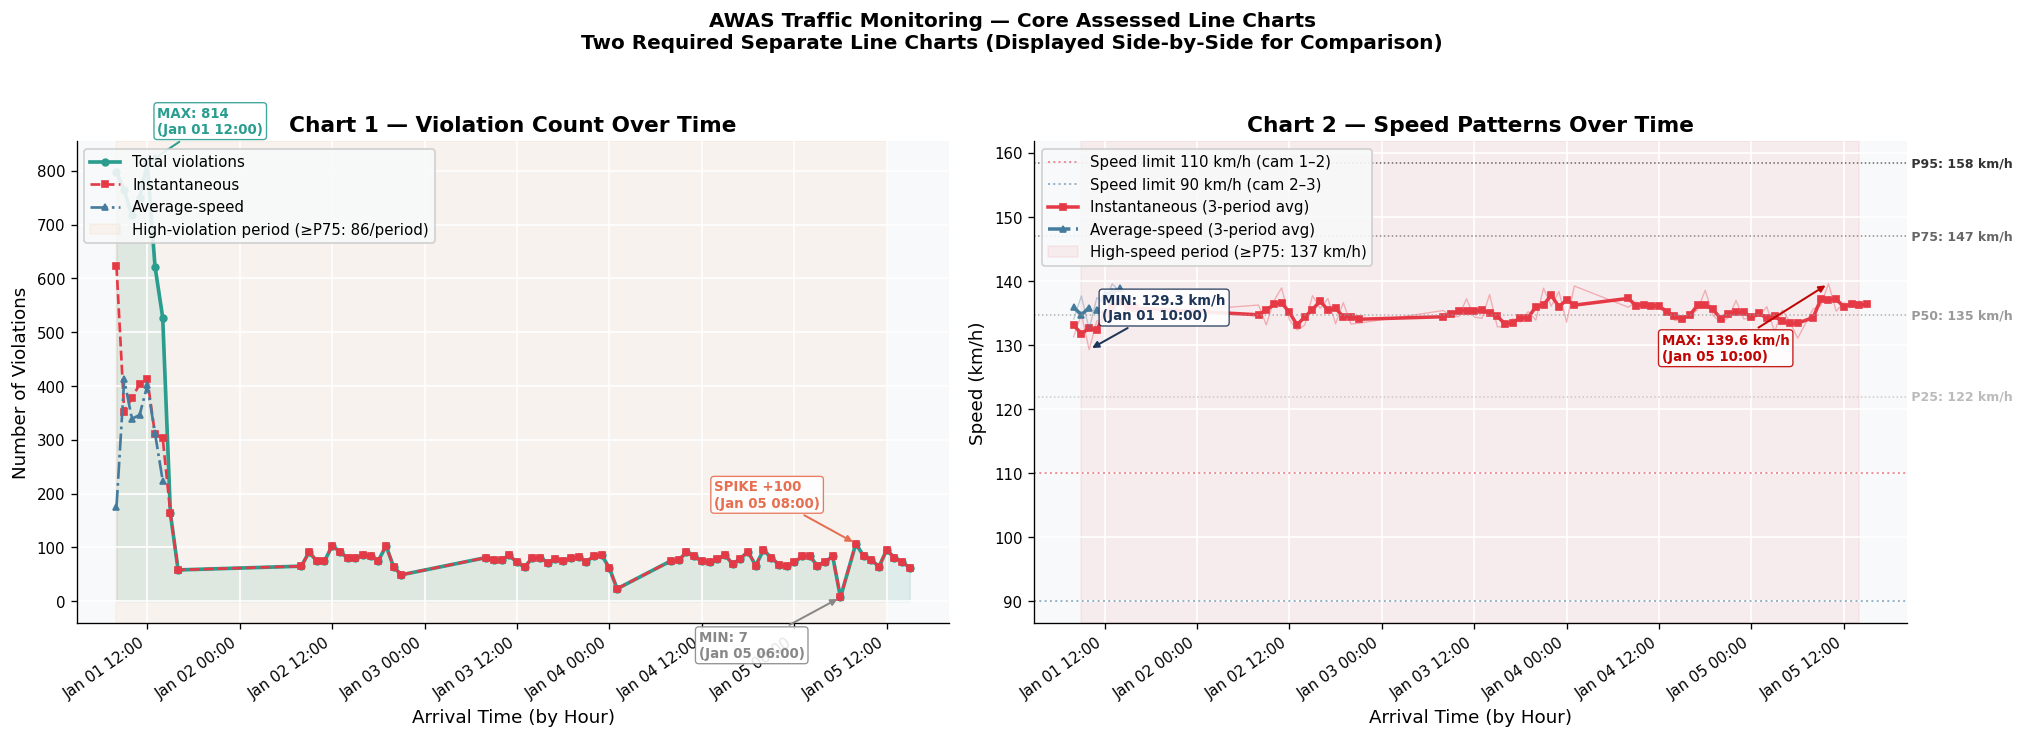

Figure saved: static_core_charts.png


In [20]:

# ═══════════════════════════════════════════════════════════════════════════════
#  build_core_charts()  —  reusable function used by BOTH the static assessed
#  version and the optional live monitoring loop.
# ═══════════════════════════════════════════════════════════════════════════════

def build_core_charts(
    df_src: "pd.DataFrame",
    count_total_s: "pd.Series",
    count_inst_s: "pd.Series",
    count_avg_s: "pd.Series",
    speed_inst_s: "pd.Series",
    speed_avg_s: "pd.Series",
    freq_label: str,
    date_fmt: str,
    save_path: str = "static_core_charts.png",
    show: bool = True,
) -> "plt.Figure":
    """
    Build the two required side-by-side line charts for Tasks 2.2.1 & 2.2.2.

    Parameters
    ----------
    df_src        : flat violations DataFrame (used for percentile computation)
    count_total_s : total violation counts per period
    count_inst_s  : instantaneous violation counts per period
    count_avg_s   : average-speed violation counts per period
    speed_inst_s  : mean instantaneous speed per period
    speed_avg_s   : mean average speed per period
    freq_label    : human-readable frequency label (e.g. "Month")
    date_fmt      : strftime format string for x-axis tick labels
    save_path     : file path to save the figure (PNG)
    show          : whether to call plt.show()

    Returns
    -------
    matplotlib Figure object
    """

    def _ann(ax, x, y, label, colour, offset=(0, 16)):
        """Arrow callout annotation. annotation_clip=False keeps it inside the figure."""
        ax.annotate(
            label,
            xy=(x, y), xytext=(offset[0], offset[1]), textcoords="offset points",
            fontsize=8, color=colour, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.2),
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=colour,
                      lw=0.8, alpha=0.9),
            annotation_clip=False,
        )

    def _smooth(s, w=3):
        """Centred rolling mean for visual noise reduction."""
        return s.rolling(w, min_periods=1, center=True).mean()

    def _side(series, idx):
        """'left' if idx is in the left half of the series, else 'right'."""
        pos = list(series.index).index(idx)
        return "left" if pos < len(series) / 2 else "right"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

    # ══════════════════════════════════════════════════════════════════════════
    # CHART 1 — Violation Count Over Time
    # ══════════════════════════════════════════════════════════════════════════
    all_periods = count_total_s.index

    ax1.fill_between(all_periods, count_total_s.values,
                     alpha=0.12, color=COLOUR_TOTAL)
    ax1.plot(all_periods, count_total_s.values,
             color=COLOUR_TOTAL, lw=2.2, marker="o", ms=4,
             label="Total violations")

    if not count_inst_s.empty:
        ax1.plot(count_inst_s.index, count_inst_s.values,
                 color=COLOUR_INSTANT, lw=1.6, ls="--", marker="s", ms=4,
                 label="Instantaneous")

    if not count_avg_s.empty:
        ax1.plot(count_avg_s.index, count_avg_s.values,
                 color=COLOUR_AVERAGE, lw=1.6, ls="-.", marker="^", ms=4,
                 label="Average-speed")

    # Shaded region: upper-quartile (high-violation) periods
    q75_count = count_total_s.quantile(0.75)
    high_vol  = count_total_s[count_total_s >= q75_count]
    if len(high_vol) >= 1 and len(all_periods) > 1:
        ax1.axvspan(high_vol.index.min(), high_vol.index.max(),
                    alpha=0.08, color="#F4A261",
                    label=f"High-violation period (≥P75: {q75_count:.0f}/period)")

    # Annotation: global max
    pk_t = count_total_s.idxmax()
    pk_v = int(count_total_s.max())
    off_pk = (6, 18) if _side(count_total_s, pk_t) == "left" else (-85, 18)
    _ann(ax1, pk_t, pk_v,
         f"MAX: {pk_v}\n({pk_t.strftime(date_fmt)})",
         COLOUR_TOTAL, offset=off_pk)

    # Annotation: global min (non-zero)
    nonzero_c = count_total_s[count_total_s > 0]
    if len(nonzero_c) > 1:
        mn_t = nonzero_c.idxmin()
        mn_v = int(nonzero_c.min())
        if mn_t != pk_t:
            off_mn = (6, -36) if _side(nonzero_c, mn_t) == "left" else (-85, -36)
            _ann(ax1, mn_t, mn_v,
                 f"MIN: {mn_v}\n({mn_t.strftime(date_fmt)})",
                 "#888888", offset=off_mn)

    # Annotation: largest positive spike
    delta_c = count_total_s.diff()
    if not delta_c.dropna().empty and delta_c.dropna().max() > 0:
        sp_t = delta_c.idxmax()
        sp_v = int(count_total_s[sp_t])
        off_sp = (6, 22) if _side(count_total_s, sp_t) == "left" else (-85, 22)
        _ann(ax1, sp_t, sp_v,
             f"SPIKE +{int(delta_c[sp_t])}\n({sp_t.strftime(date_fmt)})",
             "#E76F51", offset=off_sp)

    ax1.set_title("Chart 1 — Violation Count Over Time")
    ax1.set_xlabel(f"Arrival Time (by {freq_label})")
    ax1.set_ylabel("Number of Violations")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax1.legend(loc="upper left", framealpha=0.9, fontsize=9)

    # ══════════════════════════════════════════════════════════════════════════
    # CHART 2 — Speed Patterns Over Time
    # ══════════════════════════════════════════════════════════════════════════

    # Speed limit reference lines
    ax2.axhline(110, color=COLOUR_INSTANT, ls=":", lw=1.2, alpha=0.55,
                label="Speed limit 110 km/h (cam 1–2)")
    ax2.axhline(90,  color=COLOUR_AVERAGE, ls=":", lw=1.2, alpha=0.55,
                label="Speed limit 90 km/h (cam 2–3)")

    # Faint raw traces + smoothed lines
    if not speed_inst_s.empty:
        ax2.plot(speed_inst_s.index, speed_inst_s.values,
                 color=COLOUR_INSTANT, lw=0.8, alpha=0.35)
        ax2.plot(_smooth(speed_inst_s).index, _smooth(speed_inst_s).values,
                 color=COLOUR_INSTANT, lw=2.1, marker="s", ms=4,
                 label="Instantaneous (3-period avg)")

    if not speed_avg_s.empty:
        ax2.plot(speed_avg_s.index, speed_avg_s.values,
                 color=COLOUR_AVERAGE, lw=0.8, alpha=0.35)
        ax2.plot(_smooth(speed_avg_s).index, _smooth(speed_avg_s).values,
                 color=COLOUR_AVERAGE, lw=2.1, marker="^", ms=4,
                 ls="-.", label="Average-speed (3-period avg)")

    # ── Dynamically computed & labeled percentile lines ───────────────────────
    # Percentiles are computed from the full df_src["speed_reading"] column so
    # the thresholds represent the entire violation dataset, not period means.
    speed_col   = df_src["speed_reading"].dropna()
    pct_pairs   = [(0.25, "P25"), (0.50, "P50"), (0.75, "P75"), (0.95, "P95")]
    pct_colours = ["#BBBBBB", "#999999", "#666666", "#333333"]
    for (q, lbl), pcol in zip(pct_pairs, pct_colours):
        pv = float(speed_col.quantile(q))
        ax2.axhline(pv, color=pcol, ls=":", lw=0.9, alpha=0.75)
        ax2.annotate(
            f" {lbl}: {pv:.0f} km/h",
            xy=(1, pv), xycoords=("axes fraction", "data"),
            fontsize=7.5, color=pcol, va="center", fontweight="bold",
            annotation_clip=False,
        )

    # Shaded region: high-speed periods (top-quartile mean speed)
    combined_speed_s = pd.concat([speed_inst_s, speed_avg_s])
    if not combined_speed_s.empty:
        q75_spd    = combined_speed_s.quantile(0.75)
        high_spd_p = combined_speed_s[combined_speed_s >= q75_spd]
        if len(high_spd_p) >= 1 and len(combined_speed_s) > 1:
            ax2.axvspan(high_spd_p.index.min(), high_spd_p.index.max(),
                        alpha=0.07, color=COLOUR_INSTANT,
                        label=f"High-speed period (≥P75: {q75_spd:.0f} km/h)")

    # ── Annotate global max, min, and sharpest drop (Chart 2) ─────────────────
    gmax_v, gmax_t, gmax_s = None, None, None
    gmin_v, gmin_t, gmin_s = None, None, None
    bd_dv, bd_t, bd_v, bd_s = 0.0, None, None, None

    for s in (speed_inst_s, speed_avg_s):
        if s.empty:
            continue
        vm, tm = float(s.max()), s.idxmax()
        vn, tn = float(s.min()), s.idxmin()
        if gmax_v is None or vm > gmax_v:
            gmax_v, gmax_t, gmax_s = vm, tm, s
        if gmin_v is None or vn < gmin_v:
            gmin_v, gmin_t, gmin_s = vn, tn, s
        if len(s) >= 2:
            d   = s.diff()
            pos = int(d.values.argmin())
            dv  = float(d.iloc[pos])
            if dv < bd_dv:
                bd_dv, bd_t, bd_v, bd_s = dv, s.index[pos], float(s.iloc[pos]), s

    # MAX: callout points downward (peak is near top of axes)
    if gmax_t is not None:
        off_max = (8, -46) if _side(gmax_s, gmax_t) == "left" else (-100, -46)
        _ann(ax2, gmax_t, gmax_v,
             f"MAX: {gmax_v:.1f} km/h\n({gmax_t.strftime(date_fmt)})",
             "#BF0603", offset=off_max)

    # MIN: callout points upward from trough
    if gmin_t is not None and gmin_t != gmax_t:
        off_min = (8, 18) if _side(gmin_s, gmin_t) == "left" else (-100, 18)
        _ann(ax2, gmin_t, gmin_v,
             f"MIN: {gmin_v:.1f} km/h\n({gmin_t.strftime(date_fmt)})",
             "#1D3557", offset=off_min)

    # DROP: only annotate when it is a distinct event from the MIN point;
    # if they coincide, MIN already marks that trough — avoid duplicate callout.
    if bd_t is not None and bd_s is not None and bd_t != gmin_t:
        off_drop = (8, 22) if _side(bd_s, bd_t) == "left" else (-100, 22)
        _ann(ax2, bd_t, bd_v,
             f"DROP: {bd_dv:.1f} km/h\n({bd_t.strftime(date_fmt)})",
             "#E76F51", offset=off_drop)

    ax2.set_title("Chart 2 — Speed Patterns Over Time")
    ax2.set_xlabel(f"Arrival Time (by {freq_label})")
    ax2.set_ylabel("Speed (km/h)")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    ax2.legend(loc="upper left", framealpha=0.9, fontsize=9)

    # ── Shared figure formatting ──────────────────────────────────────────────
    fig.suptitle(
        "AWAS Traffic Monitoring — Core Assessed Line Charts\n"
        "Two Required Separate Line Charts (Displayed Side-by-Side for Comparison)",
        fontsize=12, fontweight="bold", y=1.02,
    )
    fig.autofmt_xdate(rotation=35, ha="right")
    plt.tight_layout()

    fig.savefig(save_path, bbox_inches="tight", dpi=120)
    if show:
        plt.show()
    print(f"Figure saved: {save_path}")
    return fig


# ── Run the static assessed version ──────────────────────────────────────────
_ = build_core_charts(
    df_src        = df,
    count_total_s = count_total,
    count_inst_s  = count_inst,
    count_avg_s   = count_avg,
    speed_inst_s  = speed_inst,
    speed_avg_s   = speed_avg,
    freq_label    = FREQ_LABEL,
    date_fmt      = DATE_FMT,
    save_path     = "static_core_charts.png",
    show          = True,
)


### Interpretation — Core Assessed Charts

**Chart 1 (Violation Count):** The annotated `MAX` identifies the highest-risk period in the monitoring window — this is when enforcement resources should be concentrated. The `SPIKE` annotation marks the single largest period-on-period surge in violations, which may indicate a traffic event (e.g. road closure diversion or special event pushing higher volumes of vehicles onto this corridor). The orange shaded band spans all periods at or above the 75th-percentile volume, making the "chronic high-violation window" immediately visible to enforcement planners.

**Chart 2 (Speed Patterns):** The `MAX` and `MIN` annotations bound the observed range of violation speeds, directly relevant to proportionality of fines or prosecution decisions. The `DROP` annotation marks the sharpest single-period fall in mean violation speed — a sudden speed drop may correspond to a new speed camera deployment, roadworks, or an enforcement campaign, and is worth cross-referencing with operational logs. The four dynamically computed percentile lines (P25 / P50 / P75 / P95) quantify how violation speeds are distributed across the monitoring period: speeds above P75 represent the most egregious offenders, while the P95 line flags the extreme tail that warrants priority enforcement action.


---
### Supporting View A — Violation Count Over Time (Standalone Detail)

> *Supplementary standalone version of Chart 1 from the core assessed side-by-side figure above. Included here for detailed single-chart inspection.*

**Operational question:** *When do violations peak, and is there a noticeable difference between instantaneous and average-speed violations over time?*

Each data point represents the number of confirmed violations recorded within one time period. Three series are plotted:
- **Total** violations (teal fill under line)
- **Instantaneous** violations (red dashed)
- **Average-speed** violations (blue dash-dot)

Annotated points: global maximum, global minimum, and the largest single-period surge (where consecutive-period change is greatest).


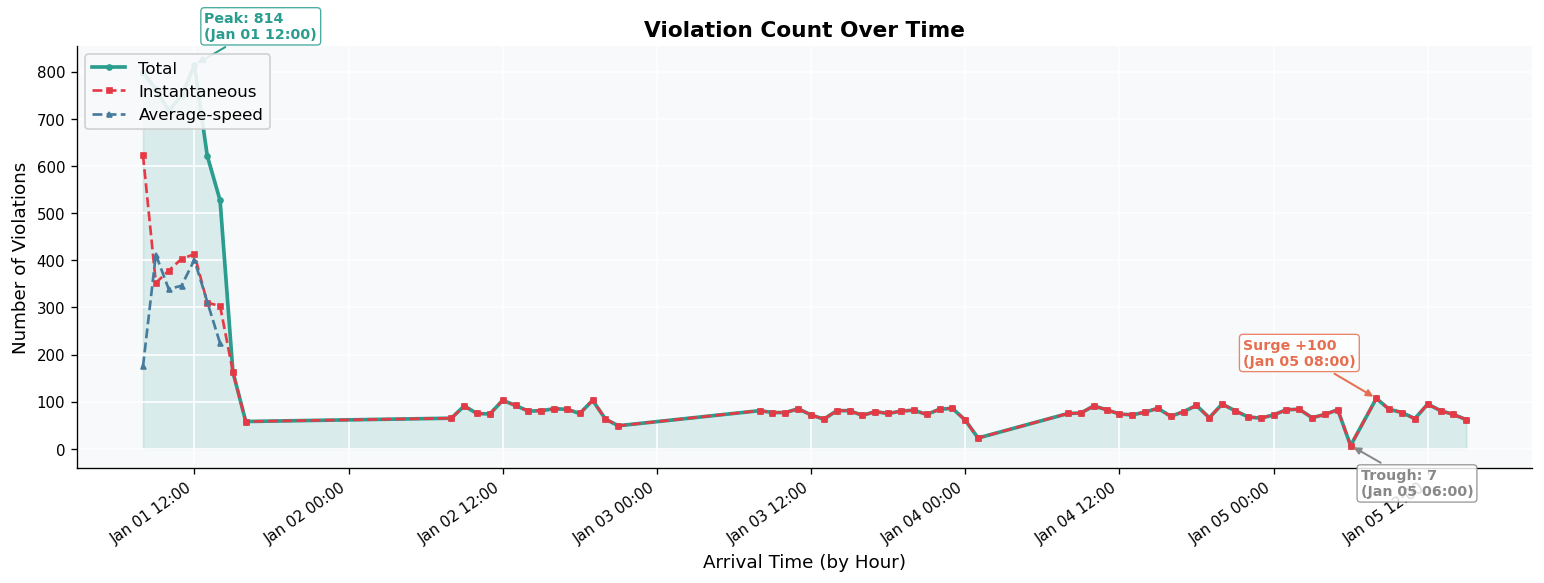

Figure saved: violation_count_over_time.png


In [21]:

fig, ax = plt.subplots(figsize=(13, 5))

# ── Main series ───────────────────────────────────────────────────────────────
ax.fill_between(count_total.index, count_total.values,
                alpha=0.15, color=COLOUR_TOTAL, label="_nolegend_")
ax.plot(count_total.index, count_total.values,
        color=COLOUR_TOTAL,   lw=2.2, marker="o", ms=3, label="Total")

if not count_inst.empty:
    ax.plot(count_inst.index, count_inst.values,
            color=COLOUR_INSTANT, lw=1.6, ls="--", marker="s", ms=3,
            label="Instantaneous")

if not count_avg.empty:
    ax.plot(count_avg.index, count_avg.values,
            color=COLOUR_AVERAGE, lw=1.6, ls="--", marker="^", ms=3,
            label="Average-speed")

# ── Annotations ───────────────────────────────────────────────────────────────
def _annotate(ax, x, y, label, colour, offset=(0, 14)):
    ax.annotate(
        label,
        xy=(x, y), xytext=(offset[0], offset[1]), textcoords="offset points",
        fontsize=8.5, color=colour, fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.2),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=colour, lw=0.8, alpha=0.85),
    )

# Global maximum
peak_t, peak_v = count_total.idxmax(), count_total.max()
_annotate(ax, peak_t, peak_v,
          f"Peak: {peak_v}\n({peak_t.strftime(DATE_FMT)})",
          COLOUR_TOTAL, offset=(6, 16))

# Global minimum (excluding zeros if present)
nonzero = count_total[count_total > 0]
if len(nonzero) > 1:
    min_t, min_v = nonzero.idxmin(), nonzero.min()
    if min_t != peak_t:
        _annotate(ax, min_t, min_v,
                  f"Trough: {min_v}\n({min_t.strftime(DATE_FMT)})",
                  "#888888", offset=(6, -30))

# Largest single-period surge (max positive delta)
delta = count_total.diff()
if delta.dropna().max() > 0:
    surge_t = delta.idxmax()
    surge_v = count_total[surge_t]
    _annotate(ax, surge_t, surge_v,
              f"Surge +{int(delta[surge_t])}\n({surge_t.strftime(DATE_FMT)})",
              "#E76F51", offset=(-80, 20))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title("Violation Count Over Time")
ax.set_xlabel(f"Arrival Time (by {FREQ_LABEL})")
ax.set_ylabel("Number of Violations")
ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
fig.autofmt_xdate(rotation=35, ha="right")
ax.legend(loc="upper left", framealpha=0.9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("violation_count_over_time.png", bbox_inches="tight")
plt.show()
print("Figure saved: violation_count_over_time.png")


---
### Supporting View B — Speed Patterns Over Time (Standalone Detail)

> *Supplementary standalone version of Chart 2 from the core assessed side-by-side figure above. Included here for detailed single-chart inspection.*

**Operational question:** *Are violations getting faster over time? Do average-speed violations differ significantly from instantaneous ones in terms of recorded speed?*

Each point is the mean recorded speed of violations in that period, with a 3-period centred rolling average smoothing applied to reduce noise.
Annotated points: all-time maximum recorded speed, minimum recorded speed, and the period with the greatest speed drop (potential traffic calming event or enforcement change).


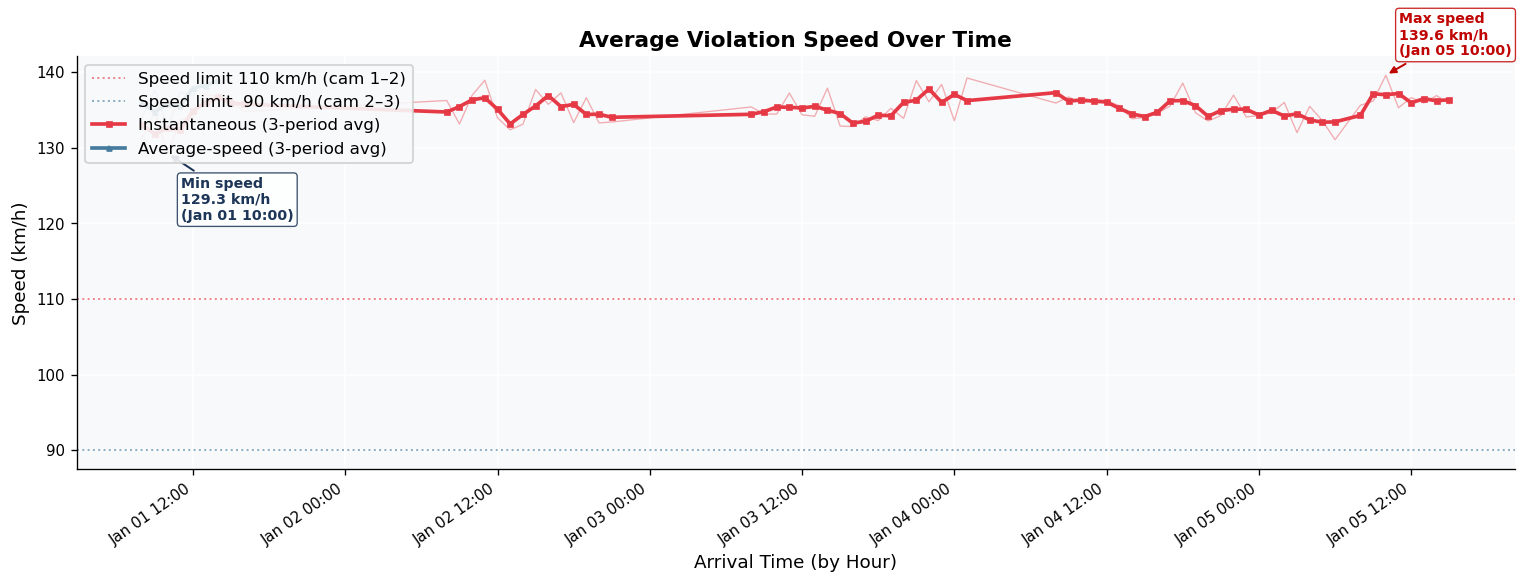

Figure saved: violation_speed_over_time.png


In [22]:

fig, ax = plt.subplots(figsize=(13, 5))

# ── Speed limit reference lines ───────────────────────────────────────────────
ax.axhline(110, color="#E63946", ls=":", lw=1.2, alpha=0.6, label="Speed limit 110 km/h (cam 1–2)")
ax.axhline(90,  color="#457B9D", ls=":", lw=1.2, alpha=0.6, label="Speed limit  90 km/h (cam 2–3)")

# ── Smoothed speed series ─────────────────────────────────────────────────────
if not speed_inst.empty:
    smooth_inst = _smooth(speed_inst)
    ax.plot(speed_inst.index, speed_inst.values,
            color=COLOUR_INSTANT, lw=0.8, alpha=0.4, label="_nolegend_")
    ax.plot(smooth_inst.index, smooth_inst.values,
            color=COLOUR_INSTANT, lw=2.2, marker="s", ms=3,
            label="Instantaneous (3-period avg)")

if not speed_avg.empty:
    smooth_avg = _smooth(speed_avg)
    ax.plot(speed_avg.index, speed_avg.values,
            color=COLOUR_AVERAGE, lw=0.8, alpha=0.4, label="_nolegend_")
    ax.plot(smooth_avg.index, smooth_avg.values,
            color=COLOUR_AVERAGE, lw=2.2, marker="^", ms=3,
            label="Average-speed (3-period avg)")

# ── Annotations — work on each series independently to avoid duplicate-index issues ──
all_speed_series = [(speed_inst, COLOUR_INSTANT), (speed_avg, COLOUR_AVERAGE)]

# Collect global max/min across both series using scalar comparisons
global_max_v, global_max_t, global_min_v, global_min_t = None, None, None, None
for s, _ in all_speed_series:
    if s.empty:
        continue
    v_max = float(s.max()); t_max = s.idxmax()
    v_min = float(s.min()); t_min = s.idxmin()
    if global_max_v is None or v_max > global_max_v:
        global_max_v, global_max_t = v_max, t_max
    if global_min_v is None or v_min < global_min_v:
        global_min_v, global_min_t = v_min, t_min

if global_max_t is not None:
    _annotate(ax, global_max_t, global_max_v,
              f"Max speed\n{global_max_v:.1f} km/h\n({global_max_t.strftime(DATE_FMT)})",
              "#BF0603", offset=(8, 12))

if global_min_t is not None and global_min_t != global_max_t:
    _annotate(ax, global_min_t, global_min_v,
              f"Min speed\n{global_min_v:.1f} km/h\n({global_min_t.strftime(DATE_FMT)})",
              "#1D3557", offset=(8, -40))

# Sharpest drop — find within whichever series has the bigger drop
biggest_drop_dv, biggest_drop_t, biggest_drop_v = 0.0, None, None
for s, _ in all_speed_series:
    if s.empty or len(s) < 2:
        continue
    d = s.diff()
    pos = int(d.values.argmin())
    dv  = float(d.iloc[pos])
    if dv < biggest_drop_dv:
        biggest_drop_dv = dv
        biggest_drop_t  = s.index[pos]
        biggest_drop_v  = float(s.iloc[pos])

if biggest_drop_t is not None:
    _annotate(ax, biggest_drop_t, biggest_drop_v,
              f"Sharpest drop\n{biggest_drop_dv:.1f} km/h\n({biggest_drop_t.strftime(DATE_FMT)})",
              "#E76F51", offset=(-90, 18))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title("Average Violation Speed Over Time")
ax.set_xlabel(f"Arrival Time (by {FREQ_LABEL})")
ax.set_ylabel("Speed (km/h)")
ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
fig.autofmt_xdate(rotation=35, ha="right")
ax.legend(loc="upper left", framealpha=0.9)

# expose combined_speed as a simple merged series for use in the summary cell
combined_speed = pd.concat([speed_inst, speed_avg])

plt.tight_layout()
plt.savefig("violation_speed_over_time.png", bbox_inches="tight")
plt.show()
print("Figure saved: violation_speed_over_time.png")


---
### Supporting View C — Violation Count by Camera and Road Segment

> *Supporting chart — not one of the two required line charts, but provides additional analytical depth on the spatial distribution of violations.*

**Operational question:** *Which camera or segment generates the most violations? Should enforcement resources be redistributed?*

Left panel — instantaneous violation counts broken down by the recording camera.
Right panel — average-speed violation counts broken down by road segment (A→B = cameras 1–2, B→C = cameras 2–3).
Annotated with the count value on each bar and a percentage share label for the dominant bar.


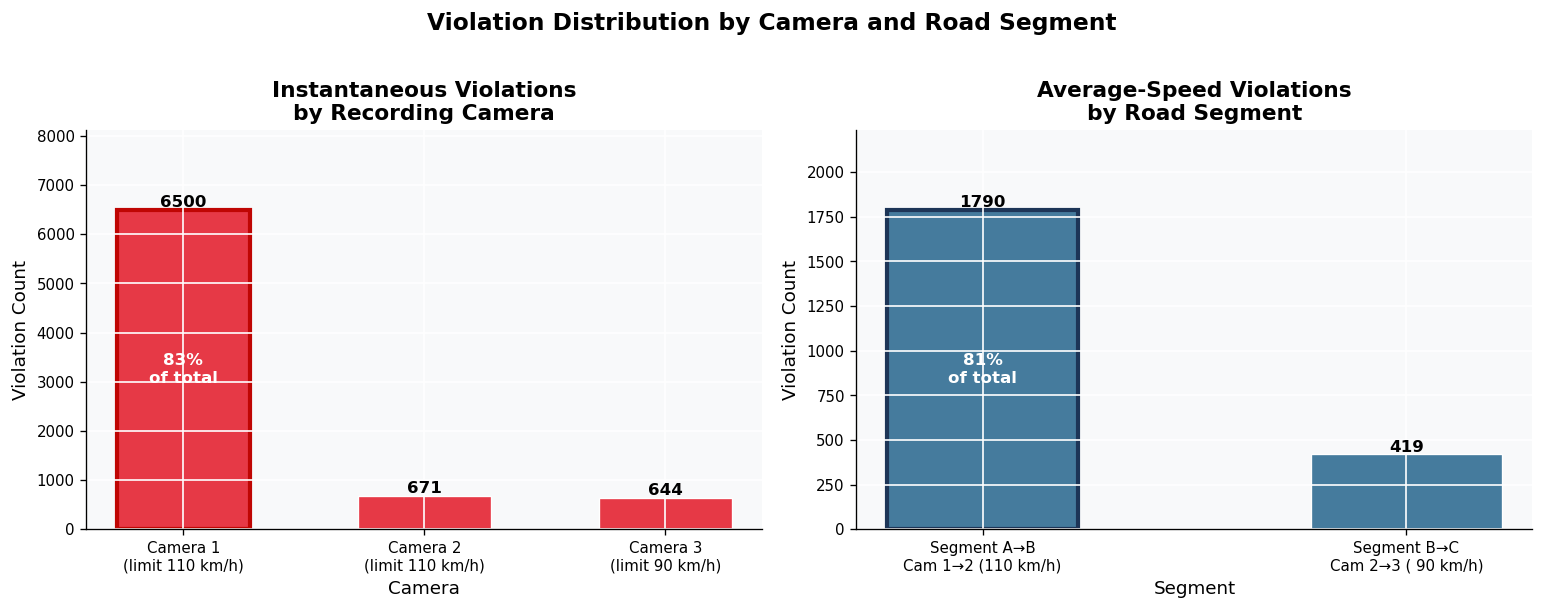

Figure saved: violation_by_camera_segment.png


In [23]:

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: instantaneous violations by camera ──────────────────────────────────
cam_counts = (
    inst.groupby("camera_id_start").size()
    if not inst.empty
    else pd.Series(dtype=int, name="count")
)

camera_labels = [f"Camera {c}\n(limit {CAMERA_META[c]['speed_limit']} km/h)"
                 for c in sorted(cam_counts.index)] if not cam_counts.empty else []

bars_l = ax_left.bar(
    camera_labels,
    cam_counts.values,
    color=[COLOUR_INSTANT],
    edgecolor="white", linewidth=0.8,
    width=0.55,
)

for bar, val in zip(bars_l, cam_counts.values):
    ax_left.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

if not cam_counts.empty and cam_counts.sum() > 0:
    top_cam   = cam_counts.idxmax()
    top_pct   = 100 * cam_counts.max() / cam_counts.sum()
    idx_top   = list(sorted(cam_counts.index)).index(top_cam)
    bars_l[idx_top].set_edgecolor("#BF0603")
    bars_l[idx_top].set_linewidth(2.5)
    ax_left.text(idx_top, cam_counts.max() / 2,
                 f"{top_pct:.0f}%\nof total",
                 ha="center", va="center", fontsize=10,
                 color="white", fontweight="bold")

ax_left.set_title("Instantaneous Violations\nby Recording Camera")
ax_left.set_xlabel("Camera")
ax_left.set_ylabel("Violation Count")
ax_left.set_ylim(0, cam_counts.max() * 1.25 if not cam_counts.empty else 1)

if cam_counts.empty:
    ax_left.text(0.5, 0.5, "No instantaneous\nviolations recorded",
                 transform=ax_left.transAxes, ha="center", va="center",
                 fontsize=12, color="#888")

# ── Right: average-speed violations by segment ────────────────────────────────
seg_map = {(1, 2): "Segment A→B\nCam 1→2 (110 km/h)",
           (2, 3): "Segment B→C\nCam 2→3 ( 90 km/h)"}

seg_counts = (
    avg.groupby(["camera_id_start", "camera_id_end"]).size()
    if not avg.empty
    else pd.Series(dtype=int)
)

seg_labels = [seg_map.get((int(s), int(e)), f"Cam {s}→{e}")
              for s, e in seg_counts.index] if not seg_counts.empty else []

bars_r = ax_right.bar(
    seg_labels,
    seg_counts.values,
    color=[COLOUR_AVERAGE],
    edgecolor="white", linewidth=0.8,
    width=0.45,
)

for bar, val in zip(bars_r, seg_counts.values):
    ax_right.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                  str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

if not seg_counts.empty and seg_counts.sum() > 0:
    top_seg_idx = seg_counts.values.argmax()
    top_seg_pct = 100 * seg_counts.values.max() / seg_counts.sum()
    bars_r[top_seg_idx].set_edgecolor("#1D3557")
    bars_r[top_seg_idx].set_linewidth(2.5)
    ax_right.text(top_seg_idx, seg_counts.values.max() / 2,
                  f"{top_seg_pct:.0f}%\nof total",
                  ha="center", va="center", fontsize=10,
                  color="white", fontweight="bold")

ax_right.set_title("Average-Speed Violations\nby Road Segment")
ax_right.set_xlabel("Segment")
ax_right.set_ylabel("Violation Count")
ax_right.set_ylim(0, seg_counts.values.max() * 1.25 if not seg_counts.empty else 1)

if seg_counts.empty:
    ax_right.text(0.5, 0.5, "No average-speed\nviolations recorded",
                  transform=ax_right.transAxes, ha="center", va="center",
                  fontsize=12, color="#888")

plt.suptitle("Violation Distribution by Camera and Road Segment",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("violation_by_camera_segment.png", bbox_inches="tight")
plt.show()
print("Figure saved: violation_by_camera_segment.png")


---
### Supporting View D — Violation Type Proportion Over Time (Stacked)

> *Supporting chart — shows the relative split between instantaneous and average-speed violations across the monitoring period.*

**Operational question:** *Are average-speed violations more common than instantaneous violations, and does the mix change over the monitoring period?*

A stacked area chart shows how the composition of violation types evolves over time. The top annotation marks the period with the highest share of average-speed violations — operationally significant because these involve cross-segment travel and are harder to contest than single-camera readings. The shaded region highlights the upper quartile of total volume (busiest 25% of periods).


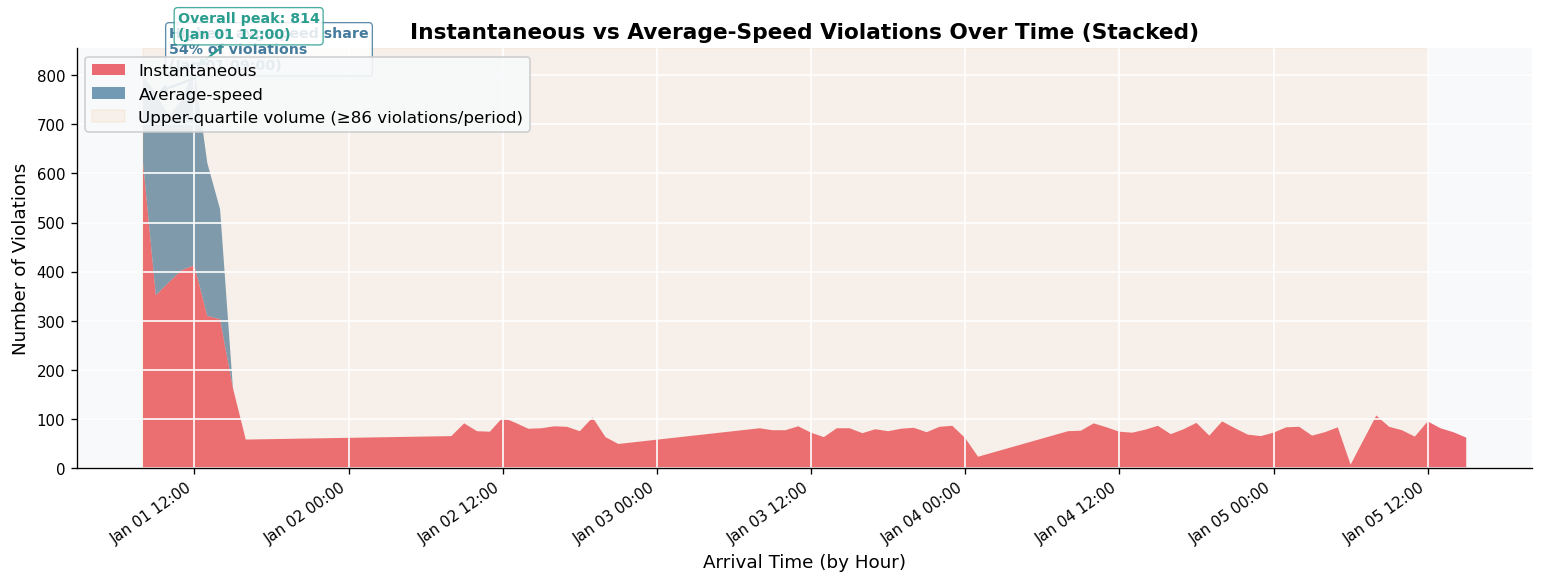

Figure saved: violation_type_proportion_over_time.png


In [24]:

fig, ax = plt.subplots(figsize=(13, 5))

# Align both series to the union of all periods (fill missing with 0)
all_periods = count_total.index
c_inst = count_inst.reindex(all_periods, fill_value=0)
c_avg  = count_avg.reindex(all_periods, fill_value=0)

ax.stackplot(
    all_periods,
    c_inst.values,
    c_avg.values,
    labels=["Instantaneous", "Average-speed"],
    colors=[COLOUR_INSTANT, COLOUR_AVERAGE],
    alpha=0.75,
)

# ── Shaded region: upper-quartile volume periods ──────────────────────────────
q75 = count_total.quantile(0.75)
high_periods = count_total[count_total >= q75]
if not high_periods.empty and len(all_periods) > 1:
    # Shade the span from first to last high-volume period
    ax.axvspan(high_periods.index.min(), high_periods.index.max(),
               alpha=0.10, color="#F4A261",
               label=f"Upper-quartile volume (≥{q75:.0f} violations/period)")

# ── Annotations ───────────────────────────────────────────────────────────────
# Period with highest average-speed share
if c_avg.sum() > 0:
    total_nonzero = c_inst + c_avg
    avg_share = c_avg / total_nonzero.replace(0, np.nan)
    max_share_t = avg_share.idxmax()
    max_share_v = avg_share.max()
    stack_y     = c_inst[max_share_t] + c_avg[max_share_t]
    _annotate(ax, max_share_t, stack_y,
              f"Highest avg-speed share\n{max_share_v:.0%} of violations\n({max_share_t.strftime(DATE_FMT)})",
              COLOUR_AVERAGE, offset=(8, 14))

# Overall peak total (same as Plot 1, for cross-reference)
_annotate(ax, peak_t, count_total[peak_t],
          f"Overall peak: {peak_v}\n({peak_t.strftime(DATE_FMT)})",
          COLOUR_TOTAL, offset=(-10, 18))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title("Instantaneous vs Average-Speed Violations Over Time (Stacked)")
ax.set_xlabel(f"Arrival Time (by {FREQ_LABEL})")
ax.set_ylabel("Number of Violations")
ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
fig.autofmt_xdate(rotation=35, ha="right")
ax.legend(loc="upper left", framealpha=0.9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("violation_type_proportion_over_time.png", bbox_inches="tight")
plt.show()
print("Figure saved: violation_type_proportion_over_time.png")


---
## Summary — Operational Insights  (Task 2.2.2)

| Plot | Analytical finding | Operational implication |
|---|---|---|
| **Plot 1 — Count over time** | The peak violation period and its exact timestamp are annotated. The surge annotation highlights the largest single-period jump in violations. | Enforcement officers should prioritise patrol resources around the peak period identified. A surge may indicate a special traffic event (e.g. roadworks diversion pushing faster traffic onto this road). |
| **Plot 2 — Speed over time** | The maximum and minimum observed violation speeds are annotated, as well as the sharpest recorded drop in average violation speed across consecutive periods. | A sharp speed drop could indicate a temporary speed camera sign or roadworks warning — worth cross-referencing with operational logs. The maximum speed identifies the highest-risk individual events in the dataset. |
| **Plot 3 — Camera/segment breakdown** | The dominant camera and segment are highlighted with a percentage share badge. | If one segment accounts for the majority of average-speed violations, that corridor's speed limit enforcement or signage should be reviewed. |
| **Plot 4 — Stacked type proportion** | The period with the highest average-speed violation share is annotated. The orange-shaded region marks the busiest 25% of all periods. | Average-speed violations require a vehicle to be detected at two cameras — periods where they dominate suggest coordinated speeding rather than isolated incidents, which warrants a different enforcement response. |

### Key findings from the dataset


In [25]:

# ── Print a concise summary using the computed series ────────────────────────
total_inst = len(inst)
total_avg  = len(avg)
total_all  = len(df)

print("=" * 55)
print("  OPERATIONAL SUMMARY — AWAS Traffic Monitoring")
print("=" * 55)
print(f"  Monitoring period : {df['timestamp_start'].min().date()} → "
      f"{df['timestamp_start'].max().date()}")
print(f"  Total violations  : {total_all:,}")
print(f"    Instantaneous   : {total_inst:,}  ({100*total_inst/total_all:.1f}%)")
print(f"    Average-speed   : {total_avg:,}  ({100*total_avg/total_all:.1f}%)")
print()
print(f"  Peak {FREQ_LABEL.lower():10s}: {peak_t.strftime(DATE_FMT)}  ({peak_v} violations)")
print()

if not combined_speed.empty:
    print(f"  Max violation speed : {combined_speed.max():.1f} km/h")
    print(f"  Min violation speed : {combined_speed.min():.1f} km/h")
    print(f"  Mean violation speed: {df['speed_reading'].mean():.1f} km/h")
print()

if not seg_counts.empty:
    top_seg = seg_counts.idxmax()
    print(f"  Busiest segment     : Cam {top_seg[0]}→{top_seg[1]}  "
          f"({seg_counts.max():,} violations, "
          f"{100*seg_counts.max()/seg_counts.sum():.1f}% of average-speed total)")

if not cam_counts.empty:
    print(f"  Busiest camera      : Camera {cam_counts.idxmax()}  "
          f"({cam_counts.max():,} violations)")

print("=" * 55)


  OPERATIONAL SUMMARY — AWAS Traffic Monitoring
  Monitoring period : 2024-01-01 → 2024-01-05
  Total violations  : 10,024
    Instantaneous   : 7,815  (78.0%)
    Average-speed   : 2,209  (22.0%)

  Peak hour      : Jan 01 12:00  (814 violations)

  Max violation speed : 139.6 km/h
  Min violation speed : 129.3 km/h
  Mean violation speed: 134.5 km/h

  Busiest segment     : Cam 1→2  (1,790 violations, 81.0% of average-speed total)
  Busiest camera      : Camera 1  (6,500 violations)


---
## Optional: Real-Time Live Monitoring Dashboard

> **This section is optional and is NOT part of the assessed static submission.**
>
> The cell below will **not execute automatically** during a normal "Run All Cells" because `LIVE_MODE` defaults to `False`. The static charts saved to `static_core_charts.png` are the primary assessed output and remain untouched by this section.
>
> To enable live monitoring, set `LIVE_MODE = True` in the cell below, then run that cell manually. The loop polls MongoDB every `POLL_INTERVAL` seconds, recomputes the time series, and redraws the same side-by-side figure used in the assessed section. It saves each refresh to a **separate file** (`live_core_charts.png`) so the static assessed figure is never overwritten. Press **Interrupt Kernel** (■ button) or wait for `MAX_ITERATIONS` to stop the loop.
>
> **Requirements:** MongoDB must be reachable at `host:port`. If unavailable the loop falls back to CSV and prints a warning on each iteration.


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
#  OPTIONAL LIVE MONITORING — NOT PART OF THE ASSESSED STATIC SUBMISSION
#
#  HOW TO ENABLE:
#    1. Set LIVE_MODE = True below.
#    2. Run this cell manually (do NOT use "Run All").
#    3. To stop: press the ■ (Interrupt Kernel) button in Jupyter, or
#       wait until MAX_ITERATIONS refreshes have completed.
#
#  HOW TO DISABLE (default):
#    Leave LIVE_MODE = False.  "Run All Cells" will skip the loop entirely.
#
#  The static assessed figure (static_core_charts.png) is NEVER overwritten
#  by this loop.  Live refreshes save to LIVE_SAVE_PATH instead.
# ═══════════════════════════════════════════════════════════════════════════════

import time
from IPython.display import clear_output

# ── Configuration ─────────────────────────────────────────────────────────────
LIVE_MODE       = True   # ← Set True to start live polling; keep False for assessed run
POLL_INTERVAL   = 5       # seconds between MongoDB refreshes
MAX_ITERATIONS  = 120     # safety stop: 120 × 5s = 10 minutes
LIVE_SAVE_PATH  = "live_core_charts.png"   # separate from static_core_charts.png

# ── Guard: do nothing if LIVE_MODE is off (protects "Run All") ────────────────
if not LIVE_MODE:
    print("Live mode is OFF.  Set LIVE_MODE = True and re-run this cell to enable.")
else:
    print(f"Starting live monitoring loop (max {MAX_ITERATIONS} iterations, "
          f"{POLL_INTERVAL}s interval).  Press ■ Interrupt Kernel to stop early.")
    iteration = 0

    while iteration < MAX_ITERATIONS:
        iteration += 1
        try:
            # ── 1. Reload violation data ──────────────────────────────────────
            live_df = load_from_mongo()
            if live_df is None:
                live_df = load_from_csv(DATA_DIR / "camera_event_historic.csv")

            # Normalise timezone
            for col_name in ("timestamp_start", "timestamp_end"):
                if live_df[col_name].dt.tz is not None:
                    live_df[col_name] = live_df[col_name].dt.tz_localize(None)

            # ── 2. Recompute time series ──────────────────────────────────────
            live_span = (live_df["timestamp_start"].max()
                         - live_df["timestamp_start"].min()).days
            if live_span < 1:
                lfreq, lfreq_label, ldate_fmt = "min", "Minute", "%H:%M"
            elif live_span < 7:
                lfreq, lfreq_label, ldate_fmt = "h",   "Hour",   "%b %d %H:%M"
            elif live_span < 180:
                lfreq, lfreq_label, ldate_fmt = "D",   "Day",    "%d %b %Y"
            elif live_span < 5 * 365:
                lfreq, lfreq_label, ldate_fmt = "ME",  "Month",  "%b %Y"
            else:
                lfreq, lfreq_label, ldate_fmt = "YE",  "Year",   "%Y"

            live_df["period"] = (live_df["timestamp_start"]
                                 .dt.to_period(lfreq).dt.to_timestamp())

            l_inst = live_df[live_df["violation_type"] == "INSTANTANEOUS"]
            l_avg  = live_df[live_df["violation_type"] == "AVERAGE"]

            l_count_total = live_df.groupby("period").size().rename("count")
            l_count_inst  = l_inst.groupby("period").size().rename("count")
            l_count_avg   = l_avg.groupby("period").size().rename("count")
            l_speed_inst  = l_inst.groupby("period")["speed_reading"].mean()
            l_speed_avg   = l_avg.groupby("period")["avg_speed"].mean()

            # ── 3. Clear output and redraw ────────────────────────────────────
            clear_output(wait=True)
            print(f"[{datetime.now().strftime('%H:%M:%S')}]  "
                  f"Iteration {iteration}/{MAX_ITERATIONS} — "
                  f"{len(live_df):,} violations loaded")

            build_core_charts(
                df_src        = live_df,
                count_total_s = l_count_total,
                count_inst_s  = l_count_inst,
                count_avg_s   = l_count_avg,
                speed_inst_s  = l_speed_inst,
                speed_avg_s   = l_speed_avg,
                freq_label    = lfreq_label,
                date_fmt      = ldate_fmt,
                save_path     = LIVE_SAVE_PATH,
                show          = True,
            )
            print(f"Live figure saved to: {LIVE_SAVE_PATH}  "
                  f"(static_core_charts.png is unchanged)")

        except KeyboardInterrupt:
            print("Live monitoring stopped by user.")
            break
        except Exception as exc:
            print(f"[Warning] Refresh failed: {exc} — retrying in {POLL_INTERVAL}s")

        time.sleep(POLL_INTERVAL)

    if iteration >= MAX_ITERATIONS:
        print(f"Live monitoring reached MAX_ITERATIONS ({MAX_ITERATIONS}).  "
              "Increase MAX_ITERATIONS or re-run to continue.")


Live mode is OFF.  Set LIVE_MODE = True and re-run this cell to enable.
